In [19]:
%load_ext autoreload
%autoreload 2
import sys
if ".." not in sys.path:
    sys.path.append("..")

from types import SimpleNamespace

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import pandas as pd

from signature.learning.signature_transform import RollingSignatureTransform, EFMSignatureTransform
from signature.learning.hyperparameters_optimization import optimize_lam_cv, grid_search_cv
import signature.tensor_algebra as ta

my_green = "#5b6c64"
my_copper = "#B56246"
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=[my_green, my_copper, "#322B4D", "#28BC9C", "#71074E"])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## SPX / VIX data

In [20]:
load_from = pd.to_datetime('1990-01-01') # pd.to_datetime('1995-01-01')  # Need at least 4 years prior to the first training day
train_start_date = pd.to_datetime('2000-01-01')
test_start_date = pd.to_datetime('2020-01-01') # pd.to_datetime('2019-01-01')
test_end_date = pd.to_datetime('2022-05-15')

load_from = pd.to_datetime('1990-01-01')
test_end_date = pd.to_datetime("2026-01-01")

In [21]:
# import yfinance as yf
# import pandas as pd
#
# # Updated Ticker Map
# # Note: International Volatility tickers are unstable on Yahoo.
# # We keep ^VIX and ^AXVI as they typically remain accessible.
# tickers = {
#     "VIX": "^VIX",             # US Volatility
#     "SPX": "^GSPC",            # US Underlying
#     "AXVI": "^AXVI",           # Australia Volatility
#     "ASJO": "^AXJO",           # Australia Underlying
#     "STOXX50E": "^STOXX50E",   # Eurozone Underlying
#     "DAX": "^GDAXI",           # Germany Underlying
#     "N225": "^N225",           # Japan Underlying
#     "NKVI.OS": "^NKVI.OS"      # Japan Volatility
# }
#
# def download_financial_data(start_date=load_from, end_date=test_end_date):
#     print(f"Downloading data...")
#
#     # auto_adjust=True fixes the FutureWarning you received
#     # actions=False speeds up the download
#     data = yf.download(
#         list(tickers.values()),
#         start=start_date,
#         end=end_date,
#         auto_adjust=True,
#         actions=False
#     )
#
#     # We extract only the 'Close' prices
#     df = data['Close']
#
#     # Rename columns back to readable names
#     inv_map = {v: k for k, v in tickers.items()}
#     df = df.rename(columns=inv_map)
#
#     # Forward fill to handle different international market holidays
#     # df = df.ffill().dropna()
#
#     return df
#
# df = download_financial_data()
#
# # Show status of what was successfully retrieved
# print("\n--- Download Results ---")
# for name in tickers.keys():
#     status = "✅ Success" if name in df.columns else "❌ Failed/Unavailable"
#     print(f"{name}: {status}")
#
# print("\nLast 5 rows of available data:")
# print(df.tail())

In [22]:
vi_underlying_dict = {
     "VIX": "SPX",             # US
     "AXVI": "ASJO",           # Australia
     "V2TX": "STOXX50E",       # Eurozone
     "VDAX": "DAX",            # Germany
     "NKVI.OS": "N225",        # Japan
}

df = pd.read_csv("data/vol_indices.csv", index_col=0)
df.index = pd.to_datetime(df.index)

## Helper functions

Shared by both the single-index model below and the multi-index "Global model" section, so the
dataset-assembly logic (and the train/test split) is defined once instead of being duplicated
per section.

In [23]:
def load_country_series(df, vol_ticker, underlying_ticker, train_start_date, test_start_date):
    """Load one country's (underlying, vol index) series and the bookkeeping needed to build
    EFM-signature features: a relative time grid, the train/test threshold expressed on that
    same relative grid, and the burn-in row count.
    """
    df_country = df[[underlying_ticker, vol_ticker]].dropna(subset=[underlying_ticker])
    index = df_country.index
    time_grid = np.array((index - index[0]).days / 365)
    test_threshold = (test_start_date - index[0]).days / 365
    dates_grid = pd.to_datetime(pd.Series(index))
    burn_in = np.where(index >= train_start_date)[0][0]
    return SimpleNamespace(
        underlying=df_country[underlying_ticker],
        vol_index=df_country[vol_ticker],
        time_grid=time_grid,
        dates_grid=dates_grid,
        test_threshold=test_threshold,
        burn_in=burn_in,
    )


def finalize_dataset(X_raw, vol_index, country, trunc, lam, **efm_kwargs):
    """Apply the EFM-signature transform and split train/test on `country.test_threshold`.

    The transform is causal -- the signature at row t only depends on the path up to and
    including row t -- so transforming the full series before splitting introduces no leakage.
    The split compares each row's date against the same calendar `test_start_date` used to
    build `country.test_threshold`, so for every index every training date is strictly before
    every test date (checked by the assertion below).
    """
    burn_in = country.burn_in
    y = np.array(vol_index[burn_in:])

    transformer = EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **efm_kwargs)
    X = transformer.fit_transform(X_raw, y)

    mask = ~np.isnan(y)
    X, y = X[mask], y[mask]
    time_grid_masked = country.time_grid[burn_in:][mask]
    dates_masked = country.dates_grid[burn_in:][mask]

    is_train = time_grid_masked < country.test_threshold
    data = SimpleNamespace(
        X=X, y=y,
        X_train=X[is_train], y_train=y[is_train],
        X_test=X[~is_train], y_test=y[~is_train],
        dates=dates_masked, dates_train=dates_masked[is_train], dates_test=dates_masked[~is_train],
        time_grid=time_grid_masked,
    )
    if data.dates_train.size and data.dates_test.size:
        assert data.dates_train.max() < data.dates_test.min(), "training dates overlap with test dates"
    return data


def regression_metrics(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), "R2": r2_score(y_true, y_pred)}


def print_train_test_metrics(y_train, y_pred_train, y_test, y_pred_test, label=None):
    if label:
        print(f"{label} metrics:")
    for split, (y_true, y_pred) in {"Train": (y_train, y_pred_train), "Test": (y_test, y_pred_test)}.items():
        m = regression_metrics(y_true, y_pred)
        print(f"  {split}: RMSE = {m['RMSE']:.4f}, R2 = {m['R2']:.4f}")


def plot_fit(dates, y, y_pred, test_start_date, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(dates, y, label="VI")
    ax.plot(dates, y_pred, "--", label="Predicted")
    ax.vlines(x=test_start_date, ymin=0.95 * np.min(y), ymax=1.05 * np.max(y), color="k")
    ax.legend(loc="upper left")
    if title:
        ax.set_title(title)
    plt.show()
    return fig

<Axes: xlabel='Date'>

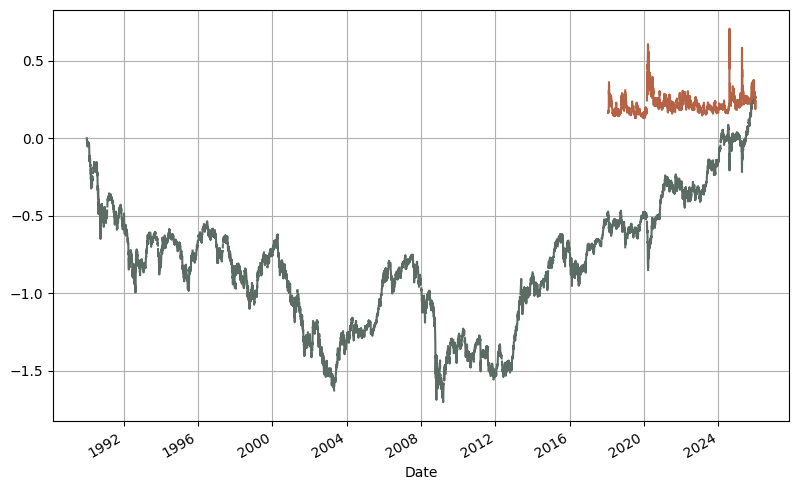

In [24]:
# Japan
np.log(df["N225"] / df["N225"].dropna().iloc[0]).plot()
(df["NKVI.OS"]).plot()

<Axes: xlabel='Date'>

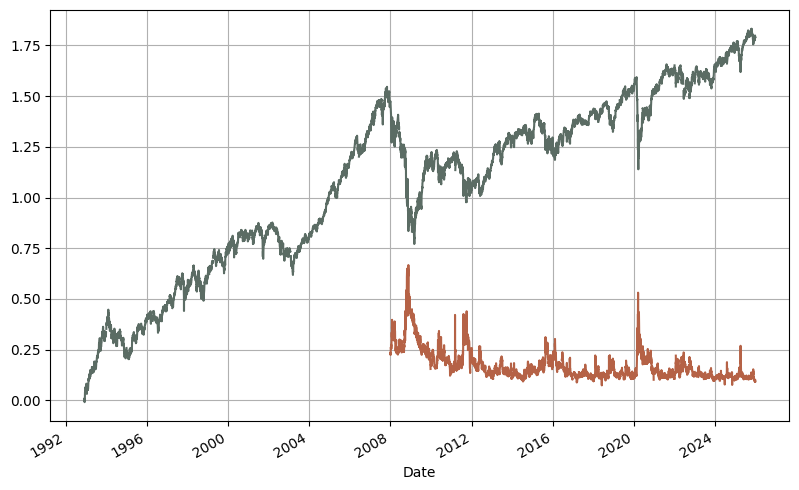

In [25]:
# Australia
(np.log(df["ASJO"] / df["ASJO"].dropna().iloc[0])).plot()
(df["AXVI"]).plot()

<Axes: xlabel='Date'>

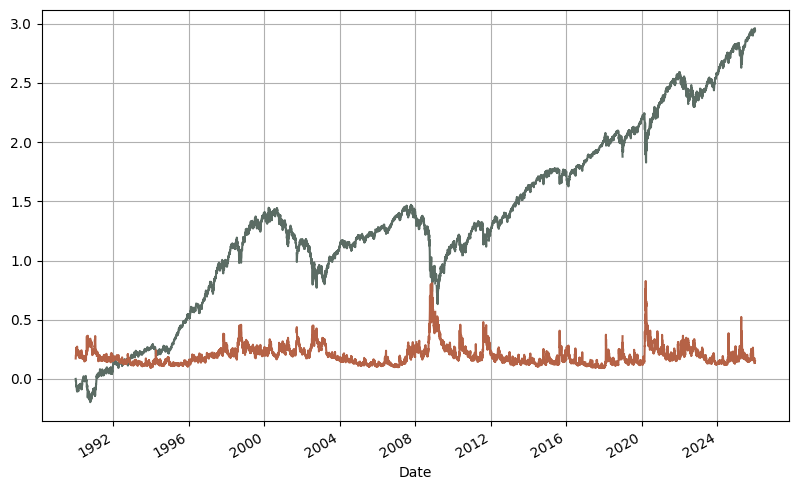

In [26]:
# US
np.log(df["SPX"] / df["SPX"].dropna().iloc[0]).plot()
(df["VIX"]).plot()

<Axes: xlabel='Date'>

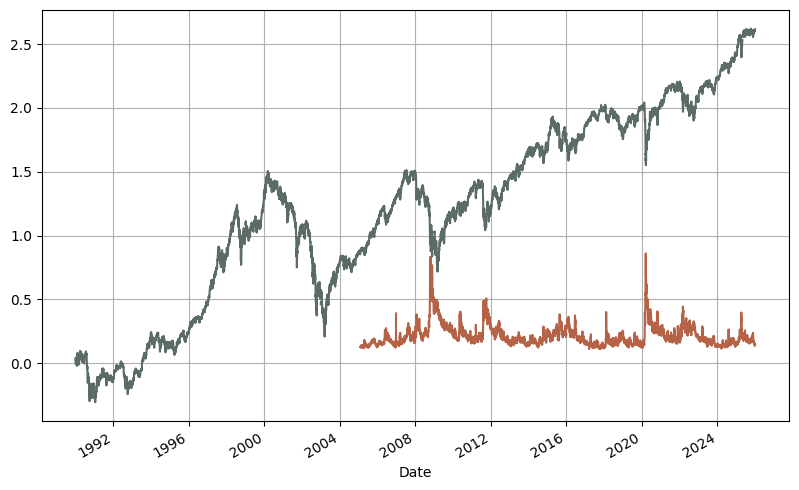

In [27]:
# Germany
np.log(df["DAX"] / df["DAX"].dropna().iloc[0]).plot()
(df["VDAX"]).plot()

<Axes: xlabel='Date'>

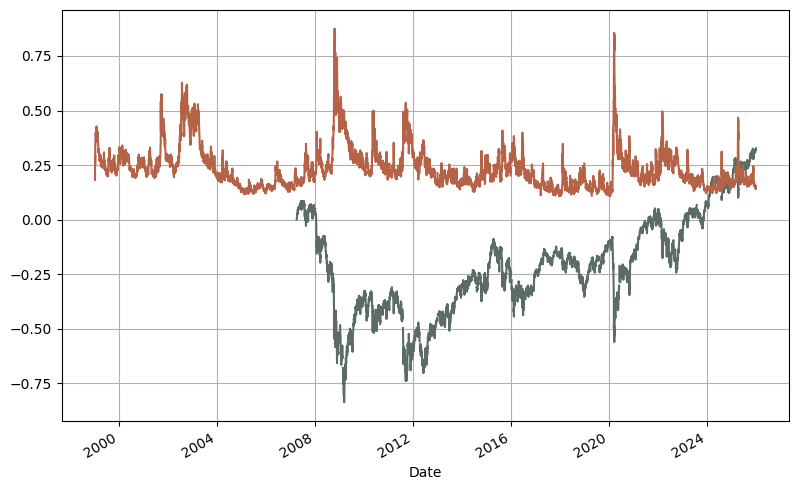

In [28]:
# Europe
np.log(df["STOXX50E"] / df["STOXX50E"].dropna().iloc[0]).plot()
(df["V2TX"]).plot()

In [31]:
volatility_index_ticker = "AXVI"  # "NKVI.OS"
stock_index_ticker = vi_underlying_dict[volatility_index_ticker]

country = load_country_series(df, volatility_index_ticker, stock_index_ticker, train_start_date, test_start_date)
underlying = country.underlying
vol_index = country.vol_index
time_grid = country.time_grid
dates_grid = country.dates_grid
burn_in = country.burn_in

print("Burn-in:", burn_in)

Burn-in: 1800


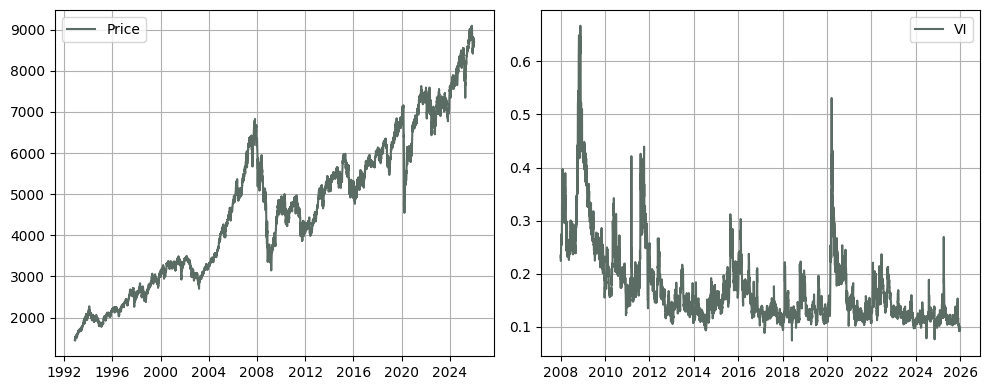

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(dates_grid, underlying, label="Price")
ax[0].legend()
# ax[1].plot(dates_grid, df_mkt.rv, label="RV")
ax[1].plot(dates_grid, vol_index, label="VI")
ax[1].legend()

## EFM-Signature model

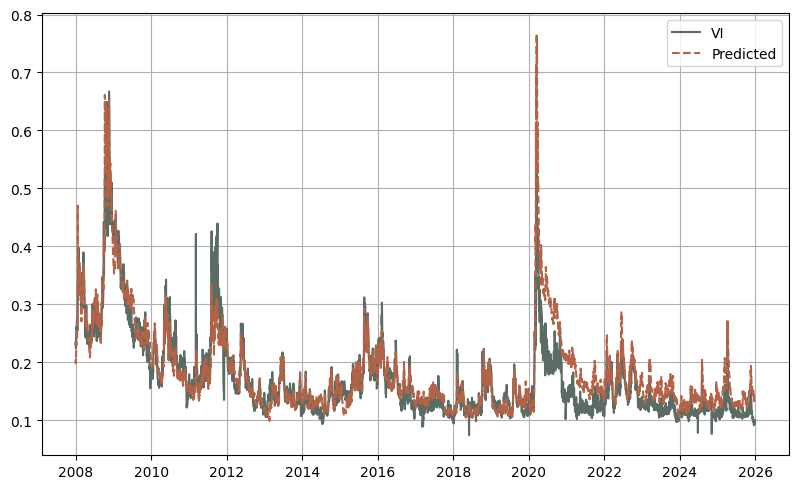

In [33]:
log_price = np.log(underlying)
quadratic_variation = np.concatenate([[0], np.cumsum(np.diff(log_price)**2)])

# path = np.vstack([
#     time_grid,
#     np.log(spx),
# ]).T
# trunc = 2
# lam = np.array([2, 8])
# kwargs = {"lead_lag": True, "lead_lag_idx": jnp.array([1]), "lam_idx": [0, 1, 1]}

path = np.vstack([
    time_grid,
    log_price / 10,
    quadratic_variation,
]).T
trunc = 2
lam = np.array([18, 12, 2])
kwargs = {}

# path = np.vstack([
#     time_grid,
#     np.log(spx),
#     np.concatenate([np.log(spx)[0:1], np.log(spx)[0:-1]]),
# ]).T
# trunc = 3
# lam = np.array([9, 1])
# kwargs = {"lam_idx": [0, 1, 1]}


dim = path.shape[1]
if "lead_lag_idx" in kwargs:
    dim += kwargs["lead_lag_idx"].size

X_raw = np.hstack([time_grid[:, None], path])
data = finalize_dataset(X_raw, vol_index, country, trunc, lam, **kwargs)

pipe = Pipeline([
    # ('sig', EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **kwargs)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

# Fit on the training window only: fitting on the full series and only later reporting
# test-period metrics (as the previous version of this cell did) leaks future information
# into the model and makes the test metrics meaningless.
pipe.fit(data.X_train, data.y_train)

plt.plot(data.dates, data.y, label="VI")
plt.plot(data.dates, pipe.predict(data.X), "--", label="Predicted")
plt.legend()

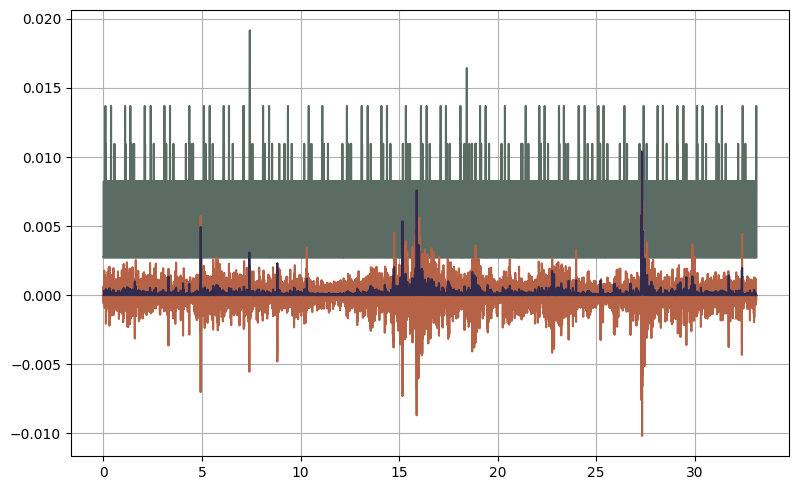

In [34]:
plt.plot(time_grid[1:], np.diff(path[:, 0], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 1], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 2], axis=0))

  Train: RMSE = 0.0229, R2 = 0.9232
  Test: RMSE = 0.0483, R2 = 0.0366


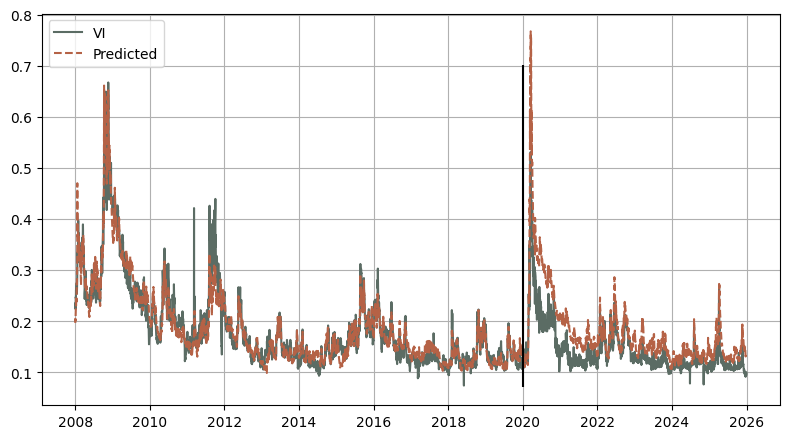

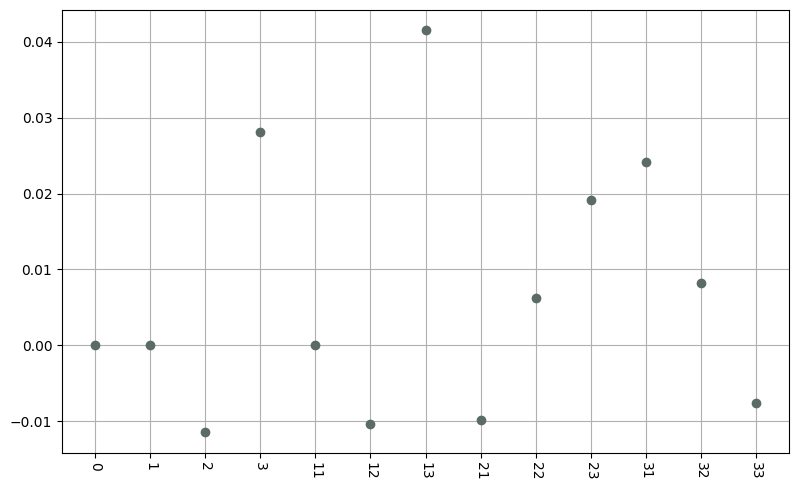

In [35]:
y_pred_train = pipe.predict(data.X_train)
y_pred_test = pipe.predict(data.X_test)
print_train_test_metrics(data.y_train, y_pred_train, data.y_test, y_pred_test)

fig = plot_fit(data.dates, data.y, pipe.predict(data.X), test_start_date)
# fig.savefig("SPX-VIX-EFM-Signature.pdf", format="pdf", transparent=True, bbox_inches="tight")

vol_coef = ta.from_array(array=pipe["regressor"].coef_, dim=dim, trunc=trunc)
ta.plot_coefficients(vol_coef, trunc=trunc)

## Global model

In [36]:
trunc = 2
lam = np.array([18, 12, 2])
kwargs = {}

# Constructing a big dataset: one EFM-signature dataset per index, each with its own
# (calendar-anchored) train/test split.
datasets = {}
for vi_ticker, underlying_ticker in vi_underlying_dict.items():
    country = load_country_series(df, vi_ticker, underlying_ticker, train_start_date, test_start_date)

    log_price = np.log(country.underlying)
    quadratic_variation = np.concatenate([[0], np.cumsum(np.diff(log_price) ** 2)])
    # vi_shifted = np.concatenate([country.vol_index[0:1], country.vol_index[:-1]])
    # integrated_shifted_vi = np.cumsum(vi_shifted)  # optional extra path column, currently unused

    path = np.vstack([
        country.time_grid,
        log_price / 10,
        quadratic_variation,
        # integrated_shifted_vi
    ]).T

    X_raw = np.hstack([country.time_grid[:, None], path])
    datasets[vi_ticker] = finalize_dataset(X_raw, country.vol_index, country, trunc, lam, **kwargs)

dim = path.shape[1]

Global metrics (trained on ['VIX', 'AXVI', 'VDAX', 'NKVI.OS'])
  Train: RMSE = 0.0242, R2 = 0.9154
  Test: RMSE = 0.0370, R2 = 0.7674


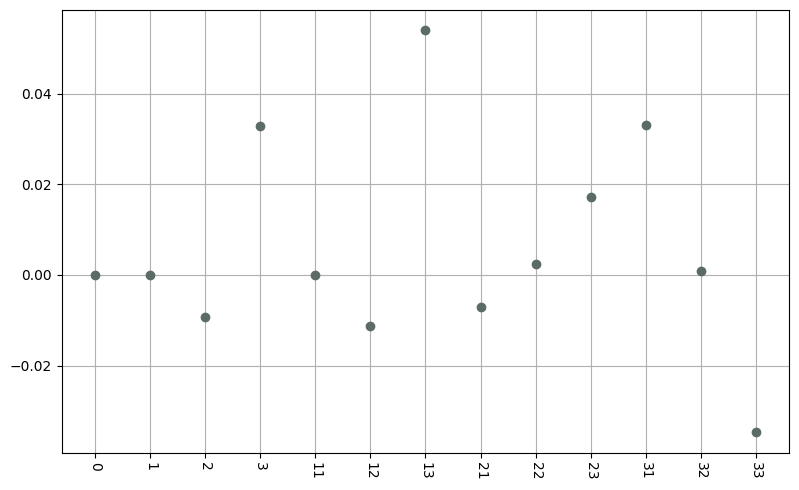

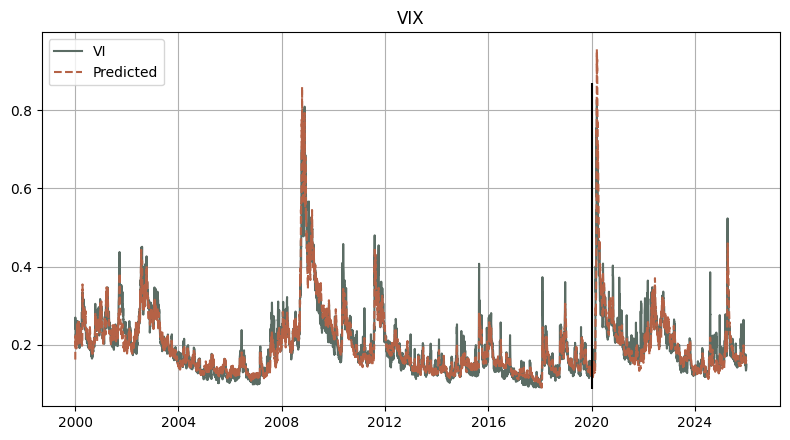

VIX metrics:
  Train: RMSE = 0.0231, R2 = 0.9256
  Test: RMSE = 0.0338, R2 = 0.8174


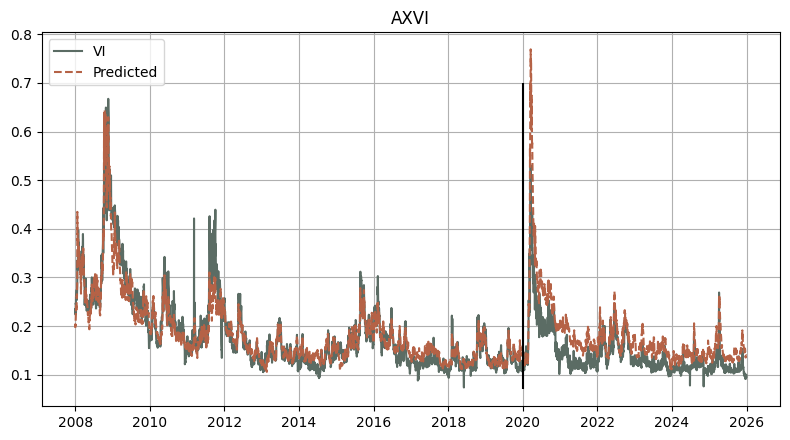

AXVI metrics:
  Train: RMSE = 0.0254, R2 = 0.9054
  Test: RMSE = 0.0470, R2 = 0.0885


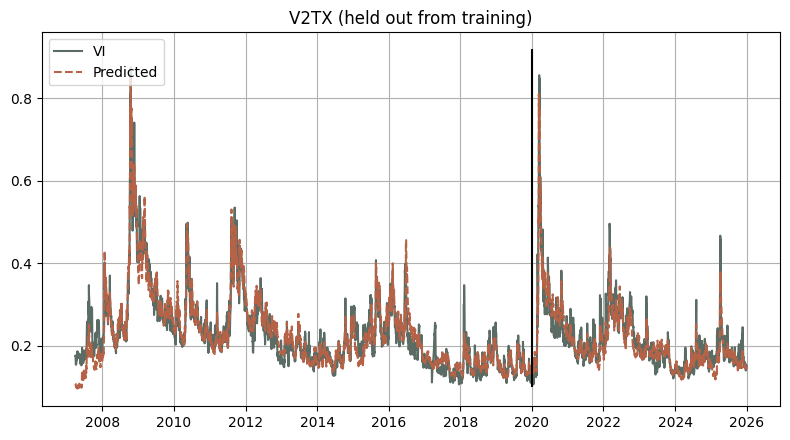

V2TX (held out from training) metrics:
  Train: RMSE = 0.0297, R2 = 0.8937
  Test: RMSE = 0.0255, R2 = 0.8969


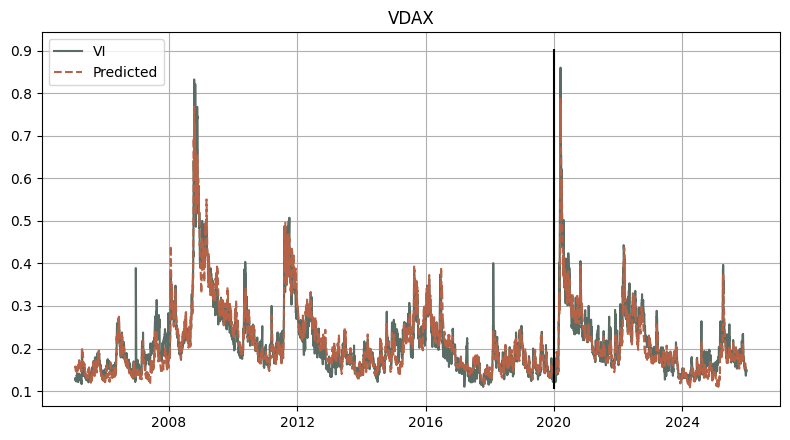

VDAX metrics:
  Train: RMSE = 0.0253, R2 = 0.9081
  Test: RMSE = 0.0238, R2 = 0.9152


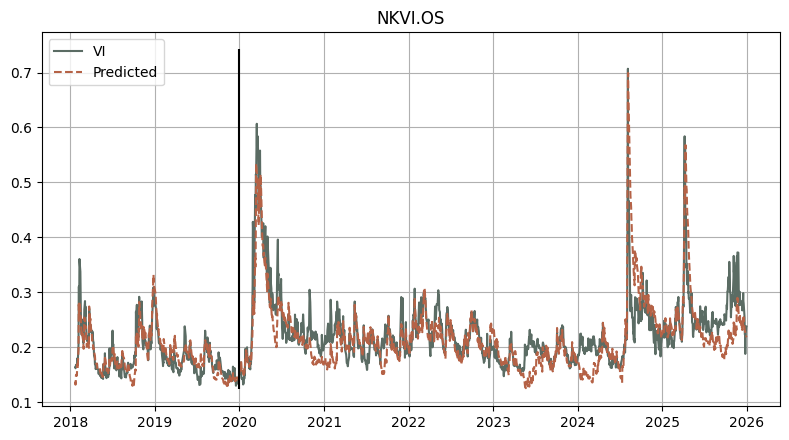

NKVI.OS metrics:
  Train: RMSE = 0.0171, R2 = 0.7956
  Test: RMSE = 0.0396, R2 = 0.5786


In [41]:
# Tickers to exclude from the *training* set. They are still evaluated below, using the model
# trained on the remaining indices -- e.g. excluded_tickers = ["VDAX"] trains on every index but
# VDAX and reports VDAX metrics purely out-of-sample (both its "train" and "test" periods, since
# the model never saw any VDAX row). Set to [] to train on every index, as before.
excluded_tickers = ["V2TX"]

train_datasets = {k: d for k, d in datasets.items() if k not in excluded_tickers}

X_global_train = np.vstack([d.X_train for d in train_datasets.values()])
y_global_train = np.concatenate([d.y_train for d in train_datasets.values()])
X_global_test = np.vstack([d.X_test for d in train_datasets.values()])
y_global_test = np.concatenate([d.y_test for d in train_datasets.values()])

pipe_global = Pipeline([
    # ('sig', EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **kwargs)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=0.1))
])

# Fit only on the pooled training rows of the included tickers: fitting on the full pooled set
# (X_global/y_global, concatenation of every index's X/y) would leak each index's test-period
# information into the model.
pipe_global.fit(X_global_train, y_global_train)

y_pred_train = pipe_global.predict(X_global_train)
y_pred_test = pipe_global.predict(X_global_test)
print(f"Global metrics (trained on {list(train_datasets.keys())})")
print_train_test_metrics(y_global_train, y_pred_train, y_global_test, y_pred_test)

vol_coef = ta.from_array(array=pipe_global["regressor"].coef_, dim=dim, trunc=trunc)
ta.plot_coefficients(vol_coef, trunc=trunc)

for vi_ticker, data in datasets.items():
    label = vi_ticker + (" (held out from training)" if vi_ticker in excluded_tickers else "")
    plot_fit(data.dates, data.y, pipe_global.predict(data.X), test_start_date, title=label)

    y_pred_train = pipe_global.predict(data.X_train)
    y_pred_test = pipe_global.predict(data.X_test)
    print_train_test_metrics(data.y_train, y_pred_train, data.y_test, y_pred_test, label=label)

### Optimize the hyper-parameters

In [ ]:
# NOTE: tuning `lam` this way requires refitting the EFM-signature transform on each CV fold,
# which means `EFMSignatureTransform` must be a step inside `pipe` (e.g. named 'sig') so that
# `pipe.set_params(sig__lam=...)` and `clone(pipe).fit(...)` recompute the signature with the
# candidate lam. The pipeline above only has 'scaler' and 'regressor' steps -- `lam` is applied
# once, upfront, when building `data` via finalize_dataset() -- so this cell is left disabled
# rather than wired in. Wiring it back in would also mean passing raw (untransformed) path data
# and revisiting the NaN-handling for target gaps, since `tscv_loop` indexes into the raw,
# pre-mask arrays by row count (`X[:burn_in + train_idx[-1] + 1]`), which the current
# drop-NaN-rows-after-transform approach is incompatible with.

# lam_dim = lam.size
# lam_opt = optimize_lam_cv(X=data.X_train, y=data.y_train, model=pipe, burn_in=burn_in,
#                           bounds=[(1, 20)] * lam_dim, init_guess=[5] * lam_dim,
#                           optimizer="Powell")
# pipe.set_params(sig__lam=lam_opt)

# 0.0010586263195815357
# 0.00087 BFGS 1.492e+01  2.000e+01  1.562e+00
# 0.000826 BFGS 2.000e+00  1.000e+01  2.923e+00

# # Grid search for the rolling signature
# param_grid = {
#     'sig__trunc': [2, 3, 4],
#     'sig__window_size': np.arange(1, 11),
#     'regressor__alpha': [0.1, 1.0, 10.0]
# }
# best_params, all_results = grid_search_cv(X=data.X_train, y=data.y_train, model=pipe, param_grid=param_grid, burn_in=burn_in)
# pipe.set_params(**best_params)

### Grid Search optimization

In [ ]:
# See the note in the cell above: this grid search also relies on `pipe` containing a 'sig'
# step, which it currently does not, so it is left disabled too. The function is named
# `grid_search_efm` (the previous version of this cell called the undefined `grid_search_cv_efm`
# and didn't import it) -- fixed here for if/when this gets wired back in.

# import itertools
# from signature.learning.hyperparameters_optimization import grid_search_efm
#
# lambda_axis = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30])
# # Generate all combinations for 3D
# lambda_3d_grid = [np.array(p) for p in itertools.product(lambda_axis, repeat=3)]
#
# param_grid = {
#     'sig__lam': lambda_3d_grid,
#     'regressor__alpha': [0.1, 1.0, 10.0]
# }
#
# best_p, all_results = grid_search_efm(
#     X=data.X_train,
#     y=data.y_train,
#     model=pipe,
#     param_grid=param_grid,
#     burn_in=burn_in
# )
#
# print("\nBest Parameters Found:")
# print(best_p)